<a href="https://colab.research.google.com/github/jceltruda/Projects-in-AI-and-ML/blob/main/Project_4/ML_AI_Projects_4_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Task 1**

**Task 1: Part A**

In [ ]:
# Setup
import torch
import numpy as np
import random
import sys
import os

# Record colab environment
print("Record environment:")
print(f"Python version: {sys.version.split(' ')[0]}")
print(f"PyTorch version: {torch.__version__}")
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f"GPU Type: {gpu_name}")

# Fix seed
seed = 15
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Get nanoGPT
!git clone https://github.com/karpathy/nanoGPT.git
%cd nanoGPT
!pip install -q datasets tiktoken wandb tqdm
!python data/shakespeare_char/prepare.py

# Calculate steps_per_epoch
num_train_tokens = 1003854 # tokens in dataset
# Using default config:
batch_size = 64
block_size = 256

steps_per_epoch = int(np.floor(num_train_tokens / (batch_size * block_size)))
print(f"\nSteps per epoch: {steps_per_epoch}")
print(f" Steps in 5 epochs: {steps_per_epoch * 5}")
print(f" Steps in 50 epochs: {steps_per_epoch * 50}")
print(f" Steps in 500 epochs: {steps_per_epoch * 500}")

Record environment:
Python version: 3.12.12
PyTorch version: 2.10.0+cu128
GPU Type: NVIDIA H100 80GB HBM3
Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.24 KiB | 3.21 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens

Steps per epoch: 61
 Steps in 5 epochs: 305
 Steps in 50 epochs: 3050
 Steps in 500 epochs: 30500


In [ ]:
# Train 5 epochs
!python train.py config/train_shakespeare_char.py \
    --max_iters=305 --eval_interval=305 --always_save_checkpoint=True \
    --out_dir=out-shakespeare-char

In [ ]:
# Generate sample 1
!python sample.py \
    --out_dir=out-shakespeare-char \
    --start="ROMEO: Juliet, I want " \
    --num_samples=1 \
    --max_new_tokens=500 \
    --temperature=0.8 \
    --top_k=200

Overriding: out_dir = out-shakespeare-char
Overriding: start = ROMEO: Juliet, I want 
Overriding: num_samples = 1
Overriding: max_new_tokens = 500
Overriding: temperature = 0.8
Overriding: top_k = 200
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
ROMEO: Juliet, I want the they beidce.

SORTHUTES:
How it to of ould and On them all ands:
Whith fould all but hearlaccaue are rume.

GRER:
An I muse on the of is heart my helit.

KING RICHARD IIIII:
Your drove to heart not and.

WARWICK:
No dise his humme new have up; and the ty most made.
Bod and gook hom the shall make on thou dude evicesseest
For His and shim compooce
And sighte king thrust for ar is him shall.

RICHURD:
That Prie, I have am I lood stimbless
ards beaces and thiu him to mare no Rreats chan the may
---------------


In [ ]:
# Train 50 epochs
!python train.py config/train_shakespeare_char.py \
    --init_from='resume' --max_iters=3050 --eval_interval=2745 --always_save_checkpoint=True \
    --out_dir=out-shakespeare-char

In [ ]:
# Generate sample 2
!python sample.py \
    --out_dir=out-shakespeare-char \
    --start="ROMEO: Juliet, I want " \
    --num_samples=1 \
    --max_new_tokens=500 \
    --temperature=0.8 \
    --top_k=200

Overriding: out_dir = out-shakespeare-char
Overriding: start = ROMEO: Juliet, I want 
Overriding: num_samples = 1
Overriding: max_new_tokens = 500
Overriding: temperature = 0.8
Overriding: top_k = 200
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
ROMEO: Juliet, I want thee for thy counsel:
Long blessed the wall! what hath my dagger
My words beguiled his back that are away?

ROMEO:
And thou hast stain'd for my life to die.

JULIET:
Why, then all my life to thee the news in this self:
Thy earth-hearted wife will be so lovey'd unto:
I cannot slay the more world than my life;
For Coriolanus be so rich in his charity.

Nurse:

JULIET:
On this I'll swear when thou hast said, and soon my oath:
Thou and thy first advance is a fortnight straight:
So far soon a man! wh
---------------


In [ ]:
# Train 500 epochs
!python train.py config/train_shakespeare_char.py \
    --init_from='resume' --max_iters=30500 --eval_interval=27450 --always_save_checkpoint=True \
    --out_dir=out-shakespeare-char

In [ ]:
# Generate sample 3
!python sample.py \
    --out_dir=out-shakespeare-char \
    --start="ROMEO: Juliet, I want " \
    --num_samples=1 \
    --max_new_tokens=500 \
    --temperature=0.8 \
    --top_k=200

Overriding: out_dir = out-shakespeare-char
Overriding: start = ROMEO: Juliet, I want 
Overriding: num_samples = 1
Overriding: max_new_tokens = 500
Overriding: temperature = 0.8
Overriding: top_k = 200
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
ROMEO: Juliet, I want your wife,
And with my legs much death, as mine with power
With pay and than a change thou dost.

FRIAR LAURENCE:
For a woman's tenderness, if thou hast
A heart of wreak in thy heart. Thou speak'st not true,
When such a desperate bark of injury, thou
Apollo wouldst dine unto this assembly.

FRIAR LAURENCE:
And thou unhappy thousand men,
For ever bearing more holy at thy gracious self.

ROMEO:
I may not, sir.

ROMEO:
O, she doth teach thee and follow me.

FRIAR LAURENCE:
Hark, how they knock! Who
---------------


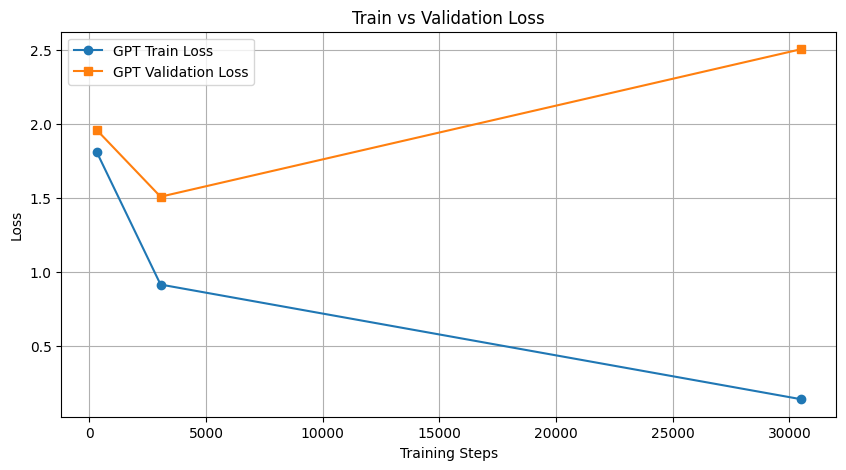

In [ ]:
import matplotlib.pyplot as plt

gpt_steps = [305, 3050, 30500]
gpt_train_losses = [1.8122, 0.9140, 0.1394]
gpt_val_losses = [1.9599, 1.5073, 2.5036]

plt.figure(figsize=(10, 5))
plt.plot(gpt_steps, gpt_train_losses, label='GPT Train Loss', marker='o')
plt.plot(gpt_steps, gpt_val_losses, label='GPT Validation Loss', marker='s')
plt.title('Train vs Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Task 1: Part B**

In [ ]:
# PyTorch LSTM Baseline
import torch.nn as nn
import pickle

# Load dataset
data_dir = 'data/shakespeare_char'
train_data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')

with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
stoi = meta['stoi']
itos = meta['itos']
vocab_size = meta['vocab_size']
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define LSTM
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size=64, hidden_size=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        out, hidden = self.lstm(embed, hidden)
        logits = self.fc(out)
        return logits, hidden

# Batch loader
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

# Initialize model
lstm_model = CharLSTM(vocab_size).to(device)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
LSTM_steps = [305, 3050, 30500]
train_losses, val_losses = [], []

print("Training LSTM:")
for step in range(1, 30501):
    lstm_model.train()
    X, Y = get_batch('train')

    logits, _ = lstm_model(X)
    loss = criterion(logits.view(-1, vocab_size), Y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step in LSTM_steps:
        lstm_model.eval()
        with torch.no_grad():
            X_val, Y_val = get_batch('val')
            val_logits, _ = lstm_model(X_val)
            val_loss = criterion(val_logits.view(-1, vocab_size), Y_val.view(-1))

        print(f"Step {step} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        # Save checkpoints
        torch.save(lstm_model.state_dict(), f"lstm_ckpt_step_{step}.pt")

Training LSTM:
Step 305 | Train Loss: 1.8237 | Val Loss: 1.9150
Step 3050 | Train Loss: 1.1538 | Val Loss: 1.5078
Step 30500 | Train Loss: 0.4412 | Val Loss: 3.2506


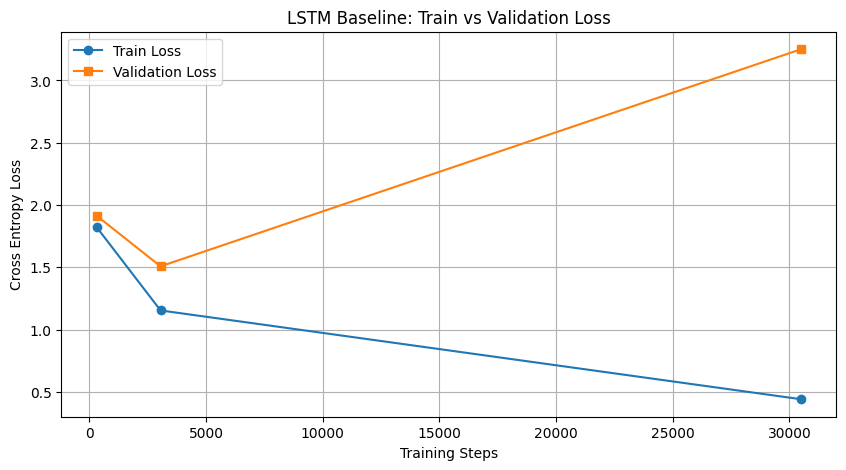

In [ ]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(LSTM_steps, train_losses, label='Train Loss', marker='o')
plt.plot(LSTM_steps, val_losses, label='Validation Loss', marker='s')
plt.title('LSTM Train vs Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# LSTM inference
import torch.nn.functional as F

def sample_lstm(model, start_text, num_chars=500, temperature=0.8, top_k=200):
    model.eval()
    chars = [stoi[c] for c in start_text]
    input_seq = torch.tensor(chars, dtype=torch.long).unsqueeze(0).to(device)
    hidden = None

    generated = start_text

    with torch.no_grad():
        for _ in range(num_chars):
            logits, hidden = model(input_seq, hidden)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')

            probs = F.softmax(logits, dim=-1)
            next_char_idx = torch.multinomial(probs, num_samples=1).item()

            generated += itos[next_char_idx]
            input_seq = torch.tensor([[next_char_idx]], device=device)

    return generated

# Load checkpoints and generate samples
for step in LSTM_steps:
    print(f"\nLSTM step: {step}")
    lstm_model.load_state_dict(torch.load(f"lstm_ckpt_step_{step}.pt"))
    print(sample_lstm(lstm_model, "ROMEO: Juliet, I want ", num_chars=500))


LSTM step: 305
ROMEO: Juliet, I want lout?
Acfain they intertes woll ast high hath crage to
gefority his pillostime ank blood,
And that thince is my diving that with with hould the bid?

CINIIUS:
Mode,
At our dome Ethere the semarre harm hast berent beant of I purtle siced;
Why mid the diduson afversted can shade.

INGONES:
Sinlelve, thy son Monan
Of in is revertet in bictioun not and thee chard,
I his made then qearse, west, lives tour firters, it meing a marter tuming;
Shall
If he his not to bnoe to wenk mey.
Where be are meaty i

LSTM step: 3050
ROMEO: Juliet, I want in thee from
thee, in the wisand takes of meed wrong'd strick was that we
pressing to wail what they achieved thee to him.

PRINCE:
They have not done him condemness, and advanced
Every word and set him for blame and friends.

ESCALUS:
The curse where I did see his house, a little nor to
her his news was the lawful king; and to my brother side
Who I may put a thankings back him.
The most dread love thy heart I may be t

**Task 1: Part C**

* Performance comparison:

  * At the first checkpoint GPT and LSTM performance was similar. Train and val loss values were close. Both output responses that had correct structure with "SPEAKER: Lines...", but the sentences were gibberish and contained non-existent words.
  * At 50 epochs, the GPT model began to outperform LSTM: .91 training loss vs 1.2, with similar val loss. The model outputs do not make contextual sense or follow a logical conversation, but grammatical errors are far fewer. I believe the GPT output is slightly more coherent and logical.
  * After 500 epochs it was difficult for me to distinguish between the text outputs of the models. They are boths structurally sound and nearly grammatically correct, but the conversations taking place do not make sense. At this point the validation losses have spiked while training losses have continued to decrease, indicating overfitting.

* Significant differences:
  * I didn't detect any significant differences in outputs, but it seems that GPT has a better grasp of the conversational context. GPT's final output seems to represent a conversation about men's desire, while the LSTM final output seems more like a collection of individual unrelated statements.
  * This is likely due to the internal hidden state architecture of the LSTM, where over time the state forgets previous tokens and only remembers more recent context. GPT uses an attention mechanism, which helps the model to understand all past tokens and relate them to the next output.